Geração de Pontos

Carregar os pacotes

In [2]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point, box
import pandas as pd
from geopandas.tools import sjoin

In [25]:
# --- PARTE 1: CONFIGURAÇÃO ---
shapefile_path = r"C:\Python\SHP\gadm41_MOZ_0.shp"

# Espaçamento em metros (ex: 1000 = 1 km)
step = 1000  

# CRS (projeção) adequado para Moçambique → UTM Zone 36S
crs_utm = "EPSG:32736"
crs_wgs84 = "EPSG:4326"

# --- PARTE 2: CARREGAR O SHAPEFILE ---
moz = gpd.read_file(shapefile_path)
moz = moz.to_crs(crs_utm)
moz = moz.explode(index_parts=False)

# --- PARTE 3: GERAR GRADE DE PONTOS COM PROJEÇÃO MÉTRICA ---
minx, miny, maxx, maxy = moz.total_bounds
x_coords = np.arange(minx, maxx, step)
y_coords = np.arange(miny, maxy, step)

points = [Point(x, y) for x in x_coords for y in y_coords]
grid = gpd.GeoDataFrame(geometry=points, crs=crs_utm)

# Spatial Join → muito mais rápido
grid_in = gpd.sjoin(grid, moz, how="inner", predicate="within").drop(columns="index_right")

# Converter de volta para latitude/longitude (WGS84)
grid_in = grid_in.to_crs(crs_wgs84)

# Adicionar ID e coordenadas
grid_in["id"] = range(1, len(grid_in) + 1)
grid_in["latitude"] = grid_in.geometry.y
grid_in["longitude"] = grid_in.geometry.x

# --- PARTE 4: EXPORTAR ---
output_csv = r"C:\Python\SHP\pontos_amostrais_utm.csv"
grid_in[["id", "latitude", "longitude"]].to_csv(output_csv, index=False)

print(f"✅ CSV gerado com sucesso: {output_csv}")


✅ CSV gerado com sucesso: C:\Python\SHP\pontos_amostrais_utm.csv


✅ CSV gerado com sucesso: C:\Python\SHP\pontos_amostrais_utm.csv
✅ GeoJSON gerado com sucesso: C:\Python\SHP\pontos_amostrais.geojson


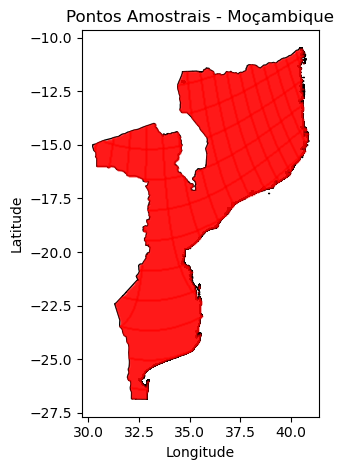

In [24]:
import geopandas as gpd
import numpy as np
from shapely.geometry import Point
import matplotlib.pyplot as plt

# --- PARTE 1: CONFIGURAÇÃO ---
shapefile_path = r"C:\Python\SHP\gadm41_MOZ_0.shp"
output_csv = r"C:\Python\SHP\pontos_amostrais_utm.csv"
output_geojson = r"C:\Python\SHP\pontos_amostrais.geojson"

# Espaçamento da grade em metros
step = 5000  

# Sistemas de referência
crs_utm = "EPSG:32736"   # UTM Zone 36S
crs_wgs84 = "EPSG:4326"  # Lat/Lon

# --- PARTE 2: CARREGAR SHAPEFILE ---
moz = gpd.read_file(shapefile_path).to_crs(crs_utm)
moz = moz.explode(index_parts=False)

# --- PARTE 3: GERAR GRADE DE PONTOS ---
minx, miny, maxx, maxy = moz.total_bounds
x_coords = np.arange(minx, maxx, step)
y_coords = np.arange(miny, maxy, step)
points = [Point(x, y) for x in x_coords for y in y_coords]
grid = gpd.GeoDataFrame(geometry=points, crs=crs_utm)

# Interseção espacial
grid_in = gpd.sjoin(grid, moz, how="inner", predicate="within").drop(columns="index_right")

# Verificação de resultado
if grid_in.empty:
    print("⚠️ Nenhum ponto foi gerado. Verifique o espaçamento ou o shapefile.")
else:
    # --- PARTE 4: CONVERTER E EXPORTAR ---
    grid_in = grid_in.to_crs(crs_wgs84)
    grid_in["id"] = range(1, len(grid_in) + 1)
    grid_in["latitude"] = grid_in.geometry.y
    grid_in["longitude"] = grid_in.geometry.x

    # Exportar CSV
    grid_in[["id", "latitude", "longitude"]].to_csv(output_csv, index=False)
    print(f"✅ CSV gerado com sucesso: {output_csv}")

    # Exportar GeoJSON
    grid_in.to_file(output_geojson, driver="GeoJSON", encoding='utf-8')
    print(f"✅ GeoJSON gerado com sucesso: {output_geojson}")


    # --- PARTE 5: VISUALIZAÇÃO ---
    moz_wgs = moz.to_crs(crs_wgs84)
    ax = moz_wgs.plot(edgecolor="black", facecolor="none")
    grid_in.plot(ax=ax, markersize=0.3, color="red", alpha=0.5)
    plt.title("Pontos Amostrais - Moçambique")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.tight_layout()
    plt.show()
